# Simulation der Steuerung einer Handprothese

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass
from scipy.integrate import solve_ivp
from itertools import product

%matplotlib inline

## Streckenparameter definieren

In [2]:
@dataclass
class PlantParams:
    J: float = 1.0       # Trägheit
    B: float = 2.0       # Dämpfung
    K: float = 0.0       # Steifigkeit
    n: float = 1.0       # Motorfaktor
    x1C: float = 110.0   # Kontaktposition (mm), hier: kein Kontakt -> max. Öffnung

params = PlantParams()

Ts = 0.01  # 10 ms Abtastzeit, siehe Sensitivitätsanalyse weiter unten

## Die ODEs als Funktion

In [3]:
def plant_dynamics(x, E, D, p: PlantParams):
    """
    x = [x1, x2] -> Position (mm), Geschwindigkeit (mm/s)
    E = Motorspannung (Stellgröße)
    D = Störung
    """
    x1, x2 = x
    dx1 = x2
    dx2 = -p.B/p.J * x2 - p.K/p.J * (p.x1C - x1) + p.n/p.J * E - D/p.J
    return np.array([dx1, dx2])

## Simulation

In [4]:
def simulate(pid, p: PlantParams, x_soll, t_end, Ts, D_func=None, x0=None):
    """
    pid: PID-Objekt/Funktion (kommt in der nächsten Zelle)
    x_soll: Sollwert (kann konstant oder Funktion von t sein)
    t_end: Simulationsdauer (s)
    Ts: Abtastzeit des Reglers (s)
    D_func: Funktion D(t) für Störung, default = 0
    x0: Anfangszustand [x1, x2], default = [0, 0]
    """
    # Falls keine Störfunktion übergeben wird, wird eine erzeugt, die immer 0 zurückgibt (also: keine Störung)
    if D_func is None:
        D_func = lambda t: 0.0
    if x0 is None:
        x0 = np.array([0.0, 0.0])

    n_steps = int(t_end / Ts)   # wie viele diskrete Zeitschritte gibt es insgesamt
    # Leere Arrays angelegen, um Ergebnisse zu speichern
    t_log = np.zeros(n_steps + 1)   # Zeitpunkte
    x_log = np.zeros((n_steps + 1, 2))  # Zustände (Position und Geschwindigkeit) zu jedem Zeitpunkt
    E_log = np.zeros(n_steps) # Motorspannungen

    # Initialisierung von aktuelle Simulationszeit t und der aktuelle Zustand x
    x = x0.copy()
    t = 0.0
    # Startzustand wird als erster Eintrag in die Logs geschrieben
    x_log[0] = x
    t_log[0] = t

    for k in range(n_steps):
        # Sollwert an diesem Zeitpunkt
        # Ist x_soll eine Funktion (dann wird sie mit der aktuellen Zeit aufgerufen)
        # oder eine feste Zahl (dann wird sie direkt verwendet)
        r = x_soll(t) if callable(x_soll) else x_soll

        # PID berechnet neue Motorspannung basierend auf aktueller Messung x[0]
        E = pid.step(r, x[0], Ts)

        # Störung wird für den aktuellen Zeitpunkt berechnet
        D = D_func(t)
        # Differentialgleichung integrieren über genau ein Abtastintervall (von t bis t+Ts)
        # E und D werden während dieses gesamten Intervalls konstant gehalten (Zero-Order-Hold)
        sol = solve_ivp(
            lambda tt, xx: plant_dynamics(xx, E, D, p),
            [t, t + Ts], x, t_eval=[t + Ts]
        )
        # Zustand am Ende dieses Intervalls wird der neue Zustand
        x = sol.y[:, -1]
        # neuer Abtastschritt
        t += Ts

        # Neue Ergebnisse in die Logs schreiben
        t_log[k+1] = t
        x_log[k+1] = x
        E_log[k] = E

    return t_log, x_log, E_log

## PID Control

In [5]:
class DiscretePID:
    def __init__(self, Kp, Ki, Kd, u_min=-np.inf, u_max=np.inf):
        # Verstärkungsfaktoren
        self.Kp = Kp
        self.Ki = Ki
        self.Kd = Kd
        # Sättigungsgrenzen (wie klein/groß ist die Motorspannung)
        self.u_min = u_min
        self.u_max = u_max
        # Startwert für die aufsummierten Fehler (Σe[j])
        self.integ = 0.0
        # letzter Fehler (e[k-1])
        self.e_prev = 0.0
        # Hilfsmerker für den allerersten Aufruf
        self.first_call = True

    def step(self, setpoint, measurement, Ts):
        # aktueller Fehler (e[k] = Sollwert - Istwert)
        e = setpoint - measurement

        # Integralanteil ohne Ki (Ts·Σe[j])
        # Fehler aufsummieren
        integ_candidate = self.integ + e * Ts

        # Differentialanteil ohne Kd
        if self.first_call:
            # Beim allerersten Aufruf gibt es noch keinen vorherigen Fehler
            # e[k - 1] = 0
            deriv = 0.0
            self.first_call = False
        else:
            deriv = (e - self.e_prev) / Ts

        # PID-Ausgang (ganze Formel zusammengesetzt)
        # "unsaturated", also bevor die Sättigungsgrenze angewendet wird
        u_unsat = self.Kp * e + self.Ki * integ_candidate + self.Kd * deriv

        # Sättigung
        # falls die berechnete Spannung außerhalb von [u_min, u_max] liegt, wird sie auf die Grenze zurückgeschnitten
        u = np.clip(u_unsat, self.u_min, self.u_max)

        # Anti-Windup: Integral nur übernehmen, wenn wir nicht sättigen
        # (oder wenn Sättigung den Fehler bereits verringern würde -> "clamping")
        if u == u_unsat:
            self.integ = integ_candidate
        # sonst: self.integ bleibt unverändert -> kein weiteres Aufwinden

        # aktueller Fehler wird zu letztem Fehler
        self.e_prev = e
        return u

    def reset(self):
        self.integ = 0.0
        self.e_prev = 0.0
        self.first_call = True

## Gütekriterien-Funktion

In [6]:
def evaluate_step_response(t, x1, r, tol=0.02):
    """
    Berechnet die Gütekriterien einer Sprungantwort.
    t: Zeitvektor
    x1: Positionsverlauf
    r: Sollwert (hier: Zielposition, z.B. 80mm)
    tol: Toleranzband um den Sollwert (Standard ±2%)
    """
    # Durch den Positionsverlauf x1 durchgehen und überall dort True setzen,
    # wo die Position schon mindestens 90% des Sollwerts erreicht hat
    # np.argmax() findet den Index des ersten True-Werts
    idx_90 = np.argmax(x1 >= 0.9 * r)
    # Anstiegszeit: Zeit bis 90% des Sollwerts erstmals erreicht sind
    # Falls die Position nie 90% erreicht, würde argmax fälschlicherweise Index 0 zurückgeben
    # Deshalb wird nochmal geprüft, ob an dieser Stelle tatsächlich x1[idx_90] >= 0.9*r gilt
    rise_time = t[idx_90] if x1[idx_90] >= 0.9 * r else np.nan

    # Überschwingen: größter Wert über dem Sollwert, in %
    overshoot = max(0.0, (np.max(x1) - r) / r * 100)

    # Einschwingzeit: letzter Zeitpunkt, an dem x1 das ±tol-Band verlässt
    # Grenzen des Toleranzbandes: Sollwert (r) ± Tolleranzwert (tol)
    lower = r * (1 - tol)
    upper = r * (1 + tol)
    # Alle Indizes der Positionen die außerhalb des Toleranzbandes liegen
    outside = np.where((x1 < lower) | (x1 > upper))[0]

    if len(outside) == 0:
        # Kein Punkt liegt außerhalb des Toleranzbandes
        # Prothese war praktisch sofort im Zielbereich
        settling_time = t[0]
    else:
        # letzter Punkt außerhalb des Toleranzbereichs ...
        last_outside = outside[-1]
        # ... war der allerletzte Zeitpunkt der ganzen Simulation
        if last_outside == len(t) - 1:
            settling_time = np.nan  # nie eingeschwungen
        # ... ist nicht der letzte Zeitpunkt
        else:
            # Einschwingzeit ist der Zeitpunkt direkt danach
            settling_time = t[last_outside + 1]

    # Fehler am Ende der Simulation
    # Sollwert minus der letzte Positionswert
    steady_state_error = r - x1[-1]

    return {
        'rise_time': rise_time,
        'settling_time': settling_time,
        'overshoot_pct': overshoot,
        'steady_state_error': steady_state_error
    }

## Gain Optimierer
Kp/Ki/Kd-Kombinationen testen

In [7]:
def cost_function(metrics, target_settling=1.0, target_overshoot=5.0):
    """
    Berechnet die Höhe der Bestrafung bei Abweichung von den Zielkriterien.
    metrics: Rückgabe von evaluate_step_response() (Dictionary mit rise_time, settling_time, overshoot_pct, steady_state_error)
    target_settling: Zielwert für settling_time
    target_overshoot: Zielwert für overshoot_pct
    """
    cost = 0.0
    if np.isnan(metrics['settling_time']):
        # nie eingeschwungen -> starke Strafe
        cost += 1000
    else:
       # Zu langsam eingeschwungen
       # -> für jede Zehntelsekunde über dem Ziel (target_settling) gibt's Strafpunkte (mit Faktor 10 gewichtet)
        cost += max(0, metrics['settling_time'] - target_settling) * 10
    # Überschwingen unter target_overshoot -> cost = 0
    # Überschwingen über target_overshoot -> cost = Differenz (für jedes Prozent über dem Ziel gibt es einen Strafpunkt)
    cost += max(0, metrics['overshoot_pct'] - target_overshoot)
    # Fehler am Ende der Simulation wird bestraft (Ziel wäre steady_state_error=0)
    cost += abs(metrics['steady_state_error']) * 5

    return cost

def grid_search(params, x_soll, t_end, Ts, u_min, u_max,
                 Kp_range, Ki_range, Kd_range):
    best_cost = np.inf
    best_gains = None
    results = []

    # product erzeugt alle Kombinationen aus den drei Wertebereichen
    for Kp, Ki, Kd in product(Kp_range, Ki_range, Kd_range):
        # Pid Regler
        pid = DiscretePID(Kp=Kp, Ki=Ki, Kd=Kd, u_min=u_min, u_max=u_max)
        # Simulation
        t_log, x_log, E_log = simulate(pid, params, x_soll=x_soll, t_end=t_end, Ts=Ts)
        # Metrics berechnen
        metrics = evaluate_step_response(t_log, x_log[:,0], r=x_soll)
        # Kosten berechnen
        cost = cost_function(metrics, x_soll)
        results.append((Kp, Ki, Kd, cost, metrics))
        if cost < best_cost:
            best_cost = cost
            best_gains = (Kp, Ki, Kd)

    return best_gains, best_cost, results

## Test

In [8]:
Kp_range = [20, 50, 100, 150, 200]
Ki_range = [20, 50, 100, 200, 300, 400, 500, 600]
Kd_range = [5, 10, 20, 30]

best_gains, best_cost, results = grid_search(
    params, x_soll=80.0, t_end=3.0, Ts=Ts,
    u_min=-300, u_max=300,   # stärkerer Motor, damit <1s überhaupt möglich ist
    Kp_range=Kp_range, Ki_range=Ki_range, Kd_range=Kd_range
)

print("Beste Gains:", best_gains, "| Cost:", best_cost)

Beste Gains: (150, 400, 20) | Cost: 0.003126050546740089


In [9]:
# Ergebnisse nach Cost sortieren, Top 5 anzeigen
sorted_results = sorted(results, key=lambda r: r[3])
for Kp, Ki, Kd, cost, metrics in sorted_results[:5]:
    print(f"Kp={Kp}, Ki={Ki}, Kd={Kd} | Cost={cost:.1f}")
    print(f"  {metrics}")

Kp=150, Ki=400, Kd=20 | Cost=0.0
  {'rise_time': np.float64(0.9100000000000006), 'settling_time': np.float64(1.440000000000001), 'overshoot_pct': np.float64(3.8518204748942075), 'steady_state_error': np.float64(0.0006252101093480178)}
Kp=200, Ki=600, Kd=30 | Cost=0.0
  {'rise_time': np.float64(0.9100000000000006), 'settling_time': np.float64(1.6200000000000012), 'overshoot_pct': np.float64(4.877031394062357), 'steady_state_error': np.float64(-0.0012516505695998603)}
Kp=150, Ki=500, Kd=20 | Cost=0.0
  {'rise_time': np.float64(0.9100000000000006), 'settling_time': np.float64(1.470000000000001), 'overshoot_pct': np.float64(4.951184365022723), 'steady_state_error': np.float64(-0.0024406850067606456)}
Kp=200, Ki=400, Kd=30 | Cost=0.0
  {'rise_time': np.float64(0.9200000000000006), 'settling_time': np.float64(1.450000000000001), 'overshoot_pct': np.float64(2.112161754327939), 'steady_state_error': np.float64(-0.004222930253206414)}
Kp=150, Ki=300, Kd=20 | Cost=0.0
  {'rise_time': np.float64(

## Beste Kombination

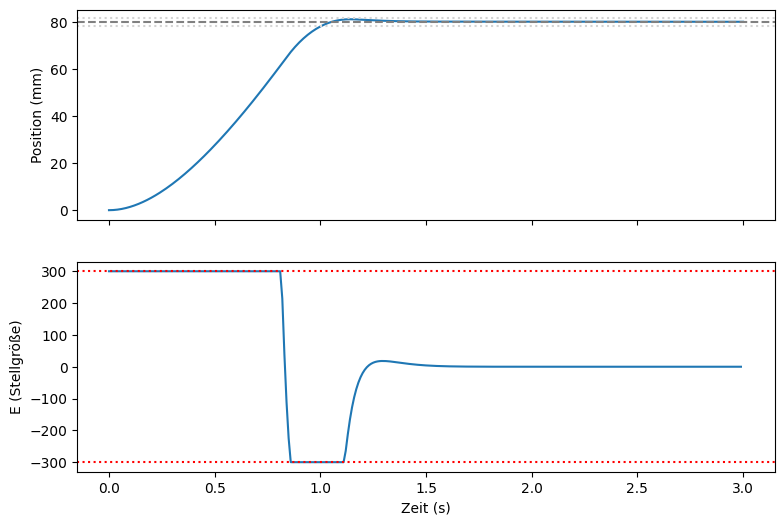

{'rise_time': np.float64(0.9100000000000006), 'settling_time': np.float64(1.0100000000000007), 'overshoot_pct': np.float64(1.4322493991758734), 'steady_state_error': np.float64(-0.08285601677937393)}


In [10]:
Kp, Ki, Kd = 150, 50, 20
pid = DiscretePID(Kp=Kp, Ki=Ki, Kd=Kd, u_min=-300, u_max=300)
t_log, x_log, E_log = simulate(pid, params, x_soll=80.0, t_end=3.0, Ts=Ts)

fig, axes = plt.subplots(2, 1, figsize=(9,6), sharex=True)
axes[0].plot(t_log, x_log[:,0])
axes[0].axhline(80, color='gray', linestyle='--')
axes[0].axhline(80*1.02, color='lightgray', linestyle=':')
axes[0].axhline(80*0.98, color='lightgray', linestyle=':')
axes[0].set_ylabel('Position (mm)')

axes[1].plot(t_log[:-1], E_log)
axes[1].axhline(300, color='red', linestyle=':')
axes[1].axhline(-300, color='red', linestyle=':')
axes[1].set_ylabel('E (Stellgröße)')
axes[1].set_xlabel('Zeit (s)')
plt.show()

metrics_best = evaluate_step_response(t_log, x_log[:,0], r=80.0)
print(metrics_best)

## Störungstest

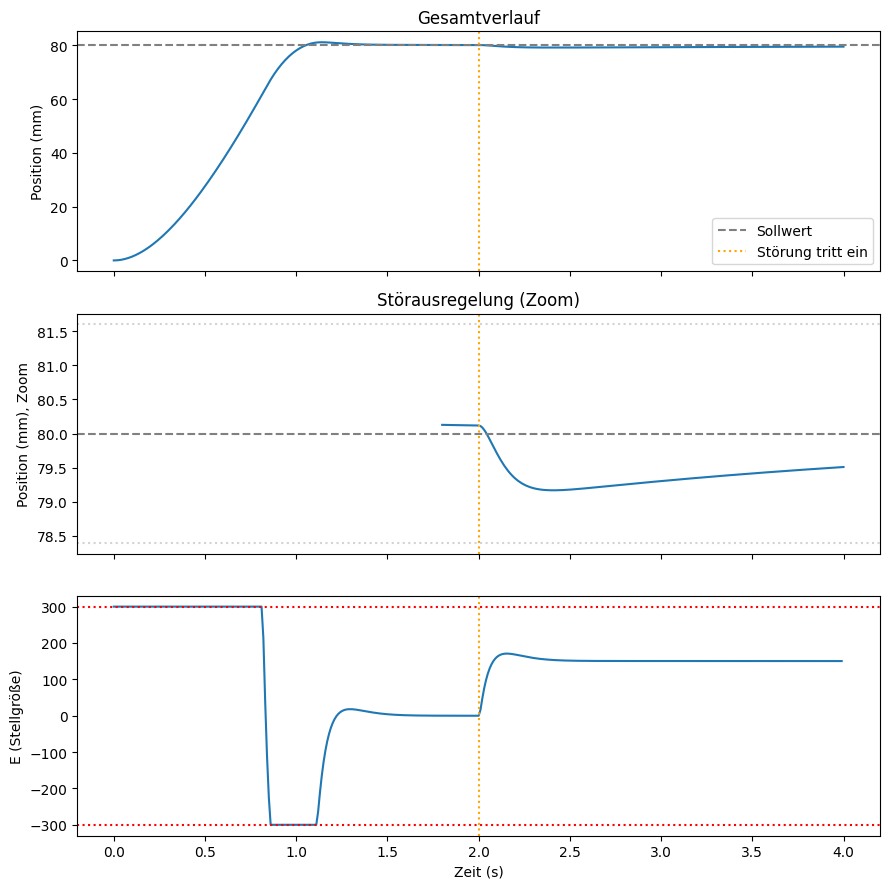

Maximale Abweichung durch Störung: 0.833 mm


In [11]:
Kp, Ki, Kd = 150, 50, 20
pid = DiscretePID(Kp=Kp, Ki=Ki, Kd=Kd, u_min=-300, u_max=300)

def D_disturbance(t):
    return 150.0 if t >= 2.0 else 0.0   # deutlich größere Störung

t_log, x_log, E_log = simulate(
    pid, params, x_soll=80.0, t_end=4.0, Ts=Ts,
    D_func=D_disturbance
)

fig, axes = plt.subplots(3, 1, figsize=(9,9), sharex=True)

# Übersicht
axes[0].plot(t_log, x_log[:,0])
axes[0].axhline(80, color='gray', linestyle='--', label='Sollwert')
axes[0].axvline(2.0, color='orange', linestyle=':', label='Störung tritt ein')
axes[0].set_ylabel('Position (mm)')
axes[0].legend()
axes[0].set_title('Gesamtverlauf')

# Zoom auf Störungsbereich
mask = (t_log >= 1.8) & (t_log <= 4.0)
axes[1].plot(t_log[mask], x_log[mask,0])
axes[1].axhline(80, color='gray', linestyle='--')
axes[1].axhline(80*1.02, color='lightgray', linestyle=':')
axes[1].axhline(80*0.98, color='lightgray', linestyle=':')
axes[1].axvline(2.0, color='orange', linestyle=':')
axes[1].set_ylabel('Position (mm), Zoom')
axes[1].set_title('Störausregelung (Zoom)')

# Stellgröße
axes[2].plot(t_log[:-1], E_log)
axes[2].axhline(300, color='red', linestyle=':')
axes[2].axhline(-300, color='red', linestyle=':')
axes[2].axvline(2.0, color='orange', linestyle=':')
axes[2].set_ylabel('E (Stellgröße)')
axes[2].set_xlabel('Zeit (s)')

plt.tight_layout()
plt.show()

# Störungsausregelung quantifizieren
mask_after = t_log >= 2.0
max_deviation = np.max(np.abs(x_log[mask_after,0] - 80.0))
print(f"Maximale Abweichung durch Störung: {max_deviation:.3f} mm")

## Sensitivitätsanalyse für verschiedene Abtastzeiten Tₛ

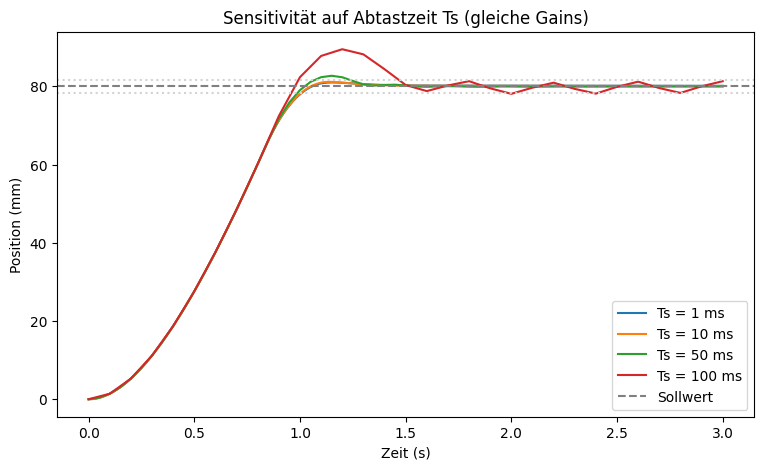

   Ts (ms) |   Rise (s) |  Settle (s) |  Overshoot % |   SS-Error
         1 |      0.910 |       1.011 |         1.24 |     -0.119
        10 |      0.910 |       1.010 |         1.43 |     -0.083
        50 |      0.950 |       1.250 |         3.37 |      0.058
       100 |      0.900 |       2.900 |        11.85 |     -1.302


In [12]:
Ts_values = [0.001, 0.01, 0.05, 0.1]  # 1ms, 10ms, 50ms, 100ms
Kp, Ki, Kd = 150, 50, 20

plt.figure(figsize=(9,5))
ts_results = {}

for Ts_test in Ts_values:
    pid = DiscretePID(Kp=Kp, Ki=Ki, Kd=Kd, u_min=-300, u_max=300)
    t_log, x_log, E_log = simulate(pid, params, x_soll=80.0, t_end=3.0, Ts=Ts_test)
    plt.plot(t_log, x_log[:,0], label=f'Ts = {Ts_test*1000:.0f} ms')

    metrics = evaluate_step_response(t_log, x_log[:,0], r=80.0)
    ts_results[Ts_test] = metrics

plt.axhline(80, color='gray', linestyle='--', label='Sollwert')
plt.axhline(80*1.02, color='lightgray', linestyle=':')
plt.axhline(80*0.98, color='lightgray', linestyle=':')
plt.xlabel('Zeit (s)')
plt.ylabel('Position (mm)')
plt.legend()
plt.title('Sensitivität auf Abtastzeit Ts (gleiche Gains)')
plt.show()

# Tabelle der Metriken
print(f"{'Ts (ms)':>10} | {'Rise (s)':>10} | {'Settle (s)':>11} | {'Overshoot %':>12} | {'SS-Error':>10}")
for Ts_test, m in ts_results.items():
    print(f"{Ts_test*1000:>10.0f} | {m['rise_time']:>10.3f} | {m['settling_time']:>11.3f} | {m['overshoot_pct']:>12.2f} | {m['steady_state_error']:>10.3f}")

## Sensitivitätsanalyse für ADC-Quantisierung

### Quantisierungsfunktion

In [13]:
def quantize(value, bits, v_min=0.0, v_max=110.0):
    """
    Rundet value auf die nächste von 2^bits diskreten Stufen im Bereich [v_min, v_max].
    """
    levels = 2**bits
    step = (v_max - v_min) / levels
    # auf nächstgelegene Stufe runden, dann zurück in echte Einheiten
    idx = np.round((value - v_min) / step)
    idx = np.clip(idx, 0, levels - 1)
    return v_min + idx * step

### Simulation mit Quantisierung

In [14]:
def simulate_quantized(pid, p: PlantParams, x_soll, t_end, Ts, bits=None,
                        v_min=0.0, v_max=110.0, D_func=None, x0=None):
    if D_func is None:
        D_func = lambda t: 0.0
    if x0 is None:
        x0 = np.array([0.0, 0.0])

    n_steps = int(t_end / Ts)
    t_log = np.zeros(n_steps + 1)
    x_log = np.zeros((n_steps + 1, 2))
    E_log = np.zeros(n_steps)

    x = x0.copy()
    t = 0.0
    x_log[0] = x
    t_log[0] = t

    for k in range(n_steps):
        r = x_soll(t) if callable(x_soll) else x_soll

        # Messung ggf. quantisieren (ADC-Effekt)
        if bits is not None:
            measured_x1 = quantize(x[0], bits, v_min, v_max)
        else:
            measured_x1 = x[0]

        E = pid.step(r, measured_x1, Ts)

        D = D_func(t)
        sol = solve_ivp(
            lambda tt, xx: plant_dynamics(xx, E, D, p),
            [t, t + Ts], x, t_eval=[t + Ts]
        )
        x = sol.y[:, -1]
        t += Ts

        t_log[k+1] = t
        x_log[k+1] = x
        E_log[k] = E

    return t_log, x_log, E_log

### Bit-Sweep

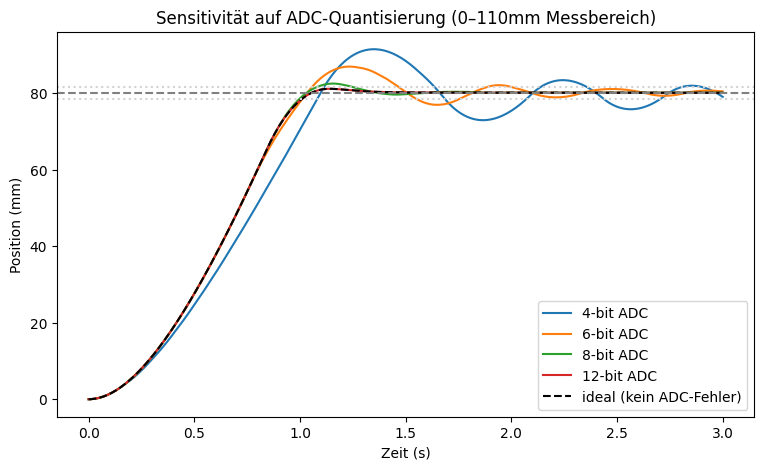

      Bits |   Rise (s) |  Settle (s) |  Overshoot % |   SS-Error
         4 |      1.020 |       2.910 |        14.35 |      0.976
         6 |      0.930 |       2.000 |         8.67 |     -0.450
         8 |      0.910 |       1.250 |         3.12 |     -0.150
        12 |      0.910 |       1.010 |         1.42 |     -0.092
     ideal |      0.910 |       1.010 |         1.43 |     -0.083


In [15]:
bit_values = [4, 6, 8, 12]   # zum Vergleich, plus None = ideal (kein Quantisierungsfehler)
Kp, Ki, Kd = 150, 50, 20

plt.figure(figsize=(9,5))
bit_results = {}

for bits in bit_values:
    pid = DiscretePID(Kp=Kp, Ki=Ki, Kd=Kd, u_min=-300, u_max=300)
    t_log, x_log, E_log = simulate_quantized(pid, params, x_soll=80.0, t_end=3.0, Ts=Ts, bits=bits)
    plt.plot(t_log, x_log[:,0], label=f'{bits}-bit ADC')
    bit_results[bits] = evaluate_step_response(t_log, x_log[:,0], r=80.0)

# Referenz: ideal, ohne Quantisierung
pid = DiscretePID(Kp=Kp, Ki=Ki, Kd=Kd, u_min=-300, u_max=300)
t_log, x_log, E_log = simulate_quantized(pid, params, x_soll=80.0, t_end=3.0, Ts=Ts, bits=None)
plt.plot(t_log, x_log[:,0], 'k--', label='ideal (kein ADC-Fehler)')
bit_results['ideal'] = evaluate_step_response(t_log, x_log[:,0], r=80.0)

plt.axhline(80, color='gray', linestyle='--')
plt.axhline(80*1.02, color='lightgray', linestyle=':')
plt.axhline(80*0.98, color='lightgray', linestyle=':')
plt.xlabel('Zeit (s)')
plt.ylabel('Position (mm)')
plt.legend()
plt.title('Sensitivität auf ADC-Quantisierung (0–110mm Messbereich)')
plt.show()

print(f"{'Bits':>10} | {'Rise (s)':>10} | {'Settle (s)':>11} | {'Overshoot %':>12} | {'SS-Error':>10}")
for bits, m in bit_results.items():
    print(f"{str(bits):>10} | {m['rise_time']:>10.3f} | {m['settling_time']:>11.3f} | {m['overshoot_pct']:>12.2f} | {m['steady_state_error']:>10.3f}")